![Imgur](https://i.imgur.com/5pXzCIu.png)

# Data Science va Sun'iy Intellekt Praktikum

## 5-MODUL. Machine Learning

### Portfolio uchun vazifa: Toshkent shahrida uylarning narxini aniqlash.

Ushbu amaliyotda sizning vazifangiz berilgan ma`lumotlar asosida Toshkent shahridagi uylarning narxini aniqlash.

In [72]:
# Data loading
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/main/housing_data_08-02-2021.csv')
df.head()

,location,district,rooms,size,level,max_levels,price
0,"город Ташкент, Юнусабадский район, Юнусабад 8-...",Юнусабадский,3,57,4,4,52000
1,"город Ташкент, Яккасарайский район, 1-й тупик ...",Яккасарайский,2,52,4,5,56000
2,"город Ташкент, Чиланзарский район, Чиланзар 2-...",Чиланзарский,2,42,4,4,37000
3,"город Ташкент, Чиланзарский район, Чиланзар 9-...",Чиланзарский,3,65,1,4,49500
4,"город Ташкент, Чиланзарский район, площадь Актепа",Чиланзарский,3,70,3,5,55000


# Ustunlar ta'rifi
- `location` - sotilayotgan uy manzili
- `district` - uy joylashgan tuman
- `rooms` - xonalar soni
- `size` - uy maydoni (kv.m)
- `level` - uy joylashgan qavat
- `max_levels` - ja'mi qavatlar soni
- `price` - uy narxi

## Vazifani CRSIP-DM Metolodgiyasi yordamida bajaring.
<img src="https://i.imgur.com/dzZnnYi.png" alt="CRISP-DM" width="800"/>

In [73]:
# Data Exploring
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   location    7565 non-null   object
 1   district    7565 non-null   object
 2   rooms       7565 non-null   int64 
 3   size        7565 non-null   object
 4   level       7565 non-null   int64 
 5   max_levels  7565 non-null   int64 
 6   price       7565 non-null   object
dtypes: int64(3), object(4)
memory usage: 413.8+ KB


In [74]:
# Data Exploring
df.describe()

,rooms,level,max_levels
count,7565.000000,7565.000000,7565.000000
mean,2.625644,3.699273,6.038202
std,1.085201,2.237275,2.613271
min,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000
50%,3.000000,3.000000,5.000000
75%,3.000000,5.000000,9.000000
max,10.000000,19.000000,25.000000


In [75]:
# Data Exploring
df.shape

(7565, 7)

In [76]:
# Data exploring
df.isna().sum()

,0
location,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,0


In [86]:
# Data Cleaning
df['price']= pd.to_numeric(df['price'], errors='coerce')
df['size']= pd.to_numeric(df['size'], errors='coerce')
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6932 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    6932 non-null   object 
 1   district    6932 non-null   object 
 2   rooms       6932 non-null   int64  
 3   size        6932 non-null   float64
 4   level       6932 non-null   int64  
 5   max_levels  6932 non-null   int64  
 6   price       6932 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 433.2+ KB


In [87]:
# Data Cleaning
df[df['price'].isna()]
df= df.dropna(subset=['price'])
df= df.dropna(subset=['size'])
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 6932 entries, 0 to 7564
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    6932 non-null   object 
 1   district    6932 non-null   object 
 2   rooms       6932 non-null   int64  
 3   size        6932 non-null   float64
 4   level       6932 non-null   int64  
 5   max_levels  6932 non-null   int64  
 6   price       6932 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 433.2+ KB


,0
location,0
district,0
rooms,0
size,0
level,0
max_levels,0
price,0


In [88]:
#Data Exploring
df.corr(numeric_only=True)

,rooms,size,level,max_levels,price
rooms,1.000000,0.831936,0.159273,0.164357,0.634740
size,0.831936,1.000000,0.229073,0.311700,0.742249
level,0.159273,0.229073,1.000000,0.599923,0.106850
max_levels,0.164357,0.311700,0.599923,1.000000,0.264607
price,0.634740,0.742249,0.106850,0.264607,1.000000


In [89]:
# Data Exploring
df[['size', 'price']].head(10)

,size,price
0,57.0,52000.0
1,52.0,56000.0
2,42.0,37000.0
3,65.0,49500.0
4,70.0,55000.0
5,28.0,25500.0
6,30.0,21200.0
7,32.0,20000.0
8,51.0,26200.0
9,30.0,22200.0


In [90]:
# Data Exploring
df.shape

(6932, 7)

In [91]:
# Remove outliers
df= df[df['size']< 300]
df['size'].describe()


,size
count,6932.000000
mean,66.977271
std,25.017967
min,1.000000
25%,50.000000
50%,64.000000
75%,80.000000
max,280.000000


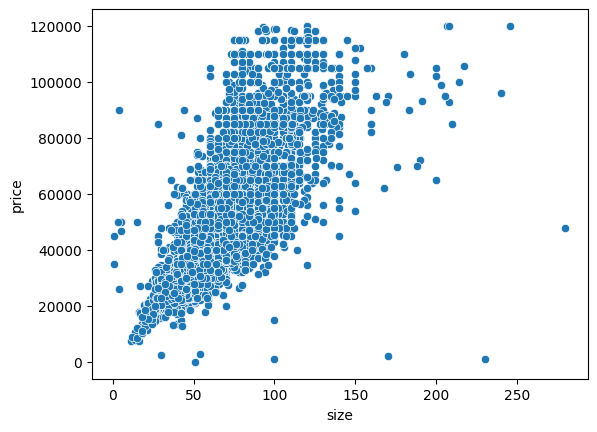

In [92]:
# Visual Exploring
 import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='size', y='price')
plt.show()

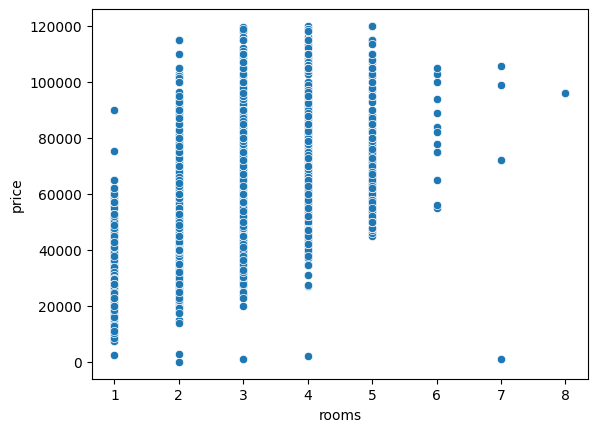

In [93]:
# Visual Exploring
sns.scatterplot(data=df, x='rooms', y='price')
plt.show()

In [94]:
# Remove outliers
df= df[df['price']<120000]
df['price'].describe()
df.shape

(6932, 7)

In [95]:
# Remove outliers
df= df.drop('location', axis=1)

In [97]:
# Feature engineering
X= df.drop('price', axis=1)
Y= df['price']

In [98]:
# Feature engineering
X= pd.get_dummies(X, columns=['district'])

In [99]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test= train_test_split(
    X,Y, test_size=0.2, random_state=42
)

In [101]:
# Train test split
X_train.shape
X_test.shape

(1387, 16)

In [102]:
# Model training
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [103]:
# Model training
model.fit(X_train, Y_train)

LinearRegression()

In [104]:
# Model training
Y_pred= model.predict(X_test)

In [105]:
import numpy as np


In [106]:
# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae= mean_absolute_error(Y_test, Y_pred)
rmse= np.sqrt(mean_squared_error(Y_test, Y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9309.543175883315
RMSE: 13199.52058210815


In [107]:
# Model Evaluation
import pandas as pd

result = pd.DataFrame({
    "Real price": Y_test,
    "Predicted price": Y_pred
})

result.head(10)

,Real price,Predicted price
5686,80000.0,56754.752147
3135,106000.0,78717.614103
413,68000.0,60235.940894
4736,29500.0,38686.164350
2946,35000.0,37594.037050
2883,32000.0,38320.960301
6716,51500.0,54103.407779
7347,32000.0,38206.550246
4028,35500.0,43475.179071
6788,85000.0,68387.046471


In [109]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']